# Défi quotidien : Classification d'images Chats vs Chiens (CNN + Augmentation de données)

Ce notebook traite l'intégralité du défi, étape par étape :
1. Chargement des données et générateurs
2. Examen des données
3. Architecture du modèle
4. Configuration de l'optimisation
5. Entraînement
6. Évaluation sur la validation
7. Inférence sur le test
8. Comparaison baseline vs augmentation
9. Gestion du déséquilibre de classes
10. Sauvegarde des artefacts
11. Extensions (BatchNorm / Transfer Learning / Mixed Precision)
12. Liste de contrôle des livrables

> ⚠️ À exécuter sur une machine disposant d'un GPU (ex. DigitalOcean) pour des temps d'entraînement raisonnables.


## 0. Imports généraux

In [ ]:
import os, math, re, random, json, time
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU disponible: []


## 1. Chargement des données et générateurs

> Téléchargez le jeu de données depuis le lien fourni dans l'énoncé, extrayez-le, renommez le
> dossier en `cats_dogs` et placez-le dans `data/`. La structure attendue est :
> `data/cats_dogs/train/train/...` et `data/cats_dogs/test/test/...`

Ce bloc construit 3 générateurs :
- `train_flow` : avec augmentation de données
- `val_flow` : redimensionnement uniquement (pas d'augmentation)
- `test_flow` : non étiqueté, pour l'inférence finale


In [ ]:
import zipfile
from pathlib import Path

zip_path = "Dogs vs Cats.zip"
extract_root = Path("data")
extract_root.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_root)

print("Extraction terminée. Contenu :")
for p in sorted(extract_root.rglob("*"))[:50]:
    print(p)

Extraction terminée. Contenu :
data/test
data/test/test
data/test/test/1.jpg
data/test/test/10.jpg
data/test/test/100.jpg
data/test/test/1000.jpg
data/test/test/10000.jpg
data/test/test/10001.jpg
data/test/test/10002.jpg
data/test/test/10003.jpg
data/test/test/10004.jpg
data/test/test/10005.jpg
data/test/test/10006.jpg
data/test/test/10007.jpg
data/test/test/10008.jpg
data/test/test/10009.jpg
data/test/test/1001.jpg
data/test/test/10010.jpg
data/test/test/10011.jpg
data/test/test/10012.jpg
data/test/test/10013.jpg
data/test/test/10014.jpg
data/test/test/10015.jpg
data/test/test/10016.jpg
data/test/test/10017.jpg
data/test/test/10018.jpg
data/test/test/10019.jpg
data/test/test/1002.jpg
data/test/test/10020.jpg
data/test/test/10021.jpg
data/test/test/10022.jpg
data/test/test/10023.jpg
data/test/test/10024.jpg
data/test/test/10025.jpg
data/test/test/10026.jpg
data/test/test/10027.jpg
data/test/test/10028.jpg
data/test/test/10029.jpg
data/test/test/1003.jpg
data/test/test/10030.jpg
data/te

In [ ]:
import os

path = "Dogs vs Cats.zip"
print("Taille du fichier (octets):", os.path.getsize(path))

with open(path, "rb") as f:
    header = f.read(16)
print("Premiers octets:", header)

Taille du fichier (octets): 856265363
Premiers octets: b'PK\x03\x04-\x00\x00\x00\x08\x00\xcc\x139OR\x84'


In [ ]:
# Chemins - à adapter si nécessaire
DATA_ROOT = Path("data")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 96, 96   # réduit depuis la résolution originale (48*48 -> ici 96*96 pour garder un peu de détail)
batch_size = 32
seed = 1337

def build_df_from_folder(folder: Path, labeled: bool = True):
    exts = ('*.jpg', '*.jpeg', '*.png', '*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        raise FileNotFoundError(f"Aucune image trouvée sous {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat", "cats"}:
                label = "cat"
            elif parent in {"dog", "dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name):
                    label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name):
                    label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

print("Train:", len(df_tr), " Val:", len(df_val), " Test:", len(df_test_full))


Train: 20000  Val: 5000  Test: 12500


In [ ]:
# Générateurs
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_flow = train_datagen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_datagen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)
test_flow = test_datagen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})


Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


## 2. Examen des données

### À faire — Analyse écrite

**Répartition par classe** : on utilise `train_flow.class_indices` (mapping nom → index)
et `train_flow.labels` (tableau des labels numériques de chaque exemple) pour compter le
nombre d'images par classe.

**Équilibre des classes** : le jeu de données Kaggle "Cats vs Dogs" est, par construction,
quasi parfaitement équilibré (~12 500 chats et ~12 500 chiens). On vérifie ce point ci-dessous
plutôt que de le supposer.

**Sources de variabilité visuelle attendues** :
- Pose de l'animal (assis, couché, de profil, de face)
- Échelle / distance de la caméra
- Éclairage (intérieur, extérieur, contre-jour)
- Arrière-plan encombré (meubles, herbe, autres objets)
- Race et couleur du pelage, très variables au sein d'une même classe

Cette variabilité justifie a posteriori les choix d'augmentation (rotation, zoom, décalage,
flip horizontal) faits en section 1.


cat    10000
dog    10000
Name: count, dtype: int64


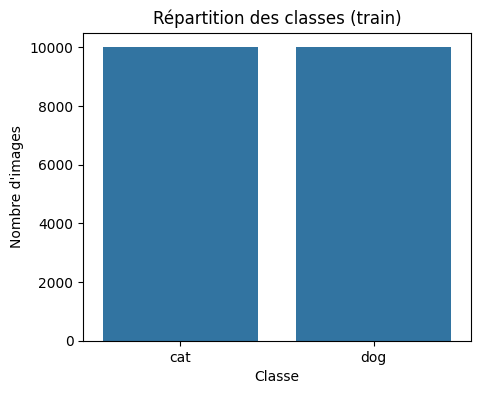

Ratio de déséquilibre: 1.00
=> Classes équilibrées


In [ ]:
# Comptage des classes
labels_arr = train_flow.labels
class_indices = train_flow.class_indices  # ex: {'cat': 0, 'dog': 1}
inv_class_indices = {v: k for k, v in class_indices.items()}

counts = pd.Series(labels_arr).map(inv_class_indices).value_counts()
print(counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Répartition des classes (train)")
plt.ylabel("Nombre d'images")
plt.xlabel("Classe")
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"Ratio de déséquilibre: {imbalance_ratio:.2f}")
print("=> Classes équilibrées" if imbalance_ratio < 1.2 else "=> Classes déséquilibrées, voir section 9")


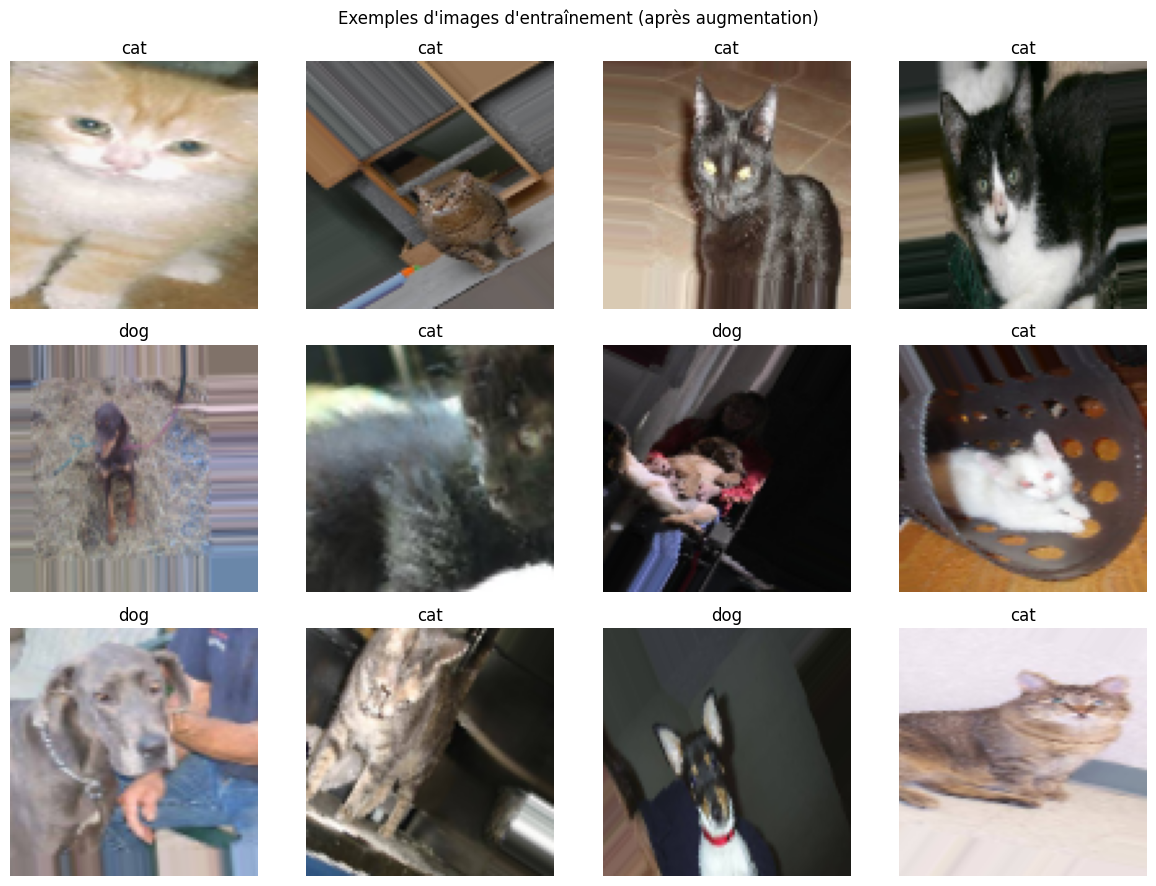

In [ ]:
# Grille d'exemples annotés
imgs, lbls = next(train_flow)
train_flow.reset()

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs):
        ax.axis('off')
        continue
    ax.imshow(imgs[i])
    label_name = inv_class_indices[int(lbls[i])]
    ax.set_title(label_name)
    ax.axis('off')
plt.suptitle("Exemples d'images d'entraînement (après augmentation)")
plt.tight_layout()
plt.show()


**Indices visuels utiles au modèle** : forme et taille des oreilles, forme du museau,
texture du pelage, posture générale du corps (les chats ont souvent une silhouette plus
compacte et arrondie, les chiens une morphologie plus variable selon la race). Le CNN devra
apprendre ces indices à partir des contours et textures locales captés par les premières
couches convolutives.


## 3. Définir l'architecture du modèle

### À faire — Description de l'architecture

- **4 blocs convolutionnels** avec un nombre croissant de filtres (32 → 64 → 128 → 128),
  noyaux 3×3, activation ReLU. La profondeur croissante permet de capter des motifs de plus
  en plus abstraits (contours → textures → parties d'objet → objet entier).
- **MaxPooling (2×2)** après chaque bloc convolutif pour réduire les dimensions spatiales,
  apporter une invariance locale aux translations et limiter le nombre de paramètres.
- **Dropout** (0.3 après les blocs convolutifs, 0.5 avant la couche de sortie) pour réduire
  le surapprentissage en désactivant aléatoirement des neurones pendant l'entraînement,
  forçant le réseau à apprendre des représentations redondantes et robustes.
- **Couches denses finales** : un `Flatten`, une couche dense de 256 unités (ReLU), puis une
  couche de sortie à **1 unité avec activation sigmoïde** (sortie = probabilité d'appartenir
  à la classe "dog"), adaptée à une cible binaire.

> **Point important** : l'entropie croisée binaire (`binary_crossentropy`) est la fonction
> de perte appropriée pour une cible de Bernoulli avec sortie sigmoïde. Softmax + entropie
> croisée catégorielle seraient utilisées pour un problème multiclasse (> 2 classes).


In [ ]:
def build_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid'),
    ])
    return model

model = build_cnn()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,993 (5.42 MB)

 Trainable params: 1,420,993 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Choisir la configuration d'optimisation

### À faire — Justification

- **Optimiseur** : `Adam`, car il combine momentum et taux d'apprentissage adaptatif par
  paramètre, ce qui donne en général une convergence rapide et stable sans réglage fin
  poussé du taux d'apprentissage initial.
- **Taux d'apprentissage initial** : `1e-3` (valeur par défaut d'Adam), raisonnable pour un
  CNN de cette taille entraîné from scratch ; on s'appuie sur `ReduceLROnPlateau` pour
  l'ajuster automatiquement si la perte de validation stagne.
- **Taille de lot (batch size)** : `32`, un bon compromis entre stabilité du gradient et
  empreinte mémoire sur un GPU/CPU standard.
- **Arrêt précoce (`EarlyStopping`)** sur `val_loss` (patience de 5 époques, restauration
  des meilleurs poids) pour stopper l'entraînement dès que la généralisation se dégrade.
- **`ReduceLROnPlateau`** sur `val_loss` pour diminuer le taux d'apprentissage quand
  l'amélioration stagne, évitant de rester bloqué sur un plateau.

> **Leçon à retenir** : on surveille à la fois la perte (`loss`) et l'exactitude
> (`accuracy`). L'exactitude peut être trompeuse en cas de déséquilibre de classes ; la
> perte est plus lisse et plus sensible à la qualité des probabilités prédites.


In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 25

def compile_model(m):
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return m

def get_callbacks(model_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
        ),
        keras.callbacks.ModelCheckpoint(
            f"{model_name}_best.h5", monitor='val_loss', save_best_only=True
        ),
    ]

model = compile_model(model)


## 5. Entraîner le modèle

### À faire

On entraîne le modèle avec augmentation, callbacks (`EarlyStopping` + `ReduceLROnPlateau`),
puis on trace les courbes d'entraînement / validation.


In [ ]:
history = model.fit(
    train_flow,
    epochs=EPOCHS,
    validation_data=val_flow,
    callbacks=get_callbacks("model_augmented"),
)


Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.5416 - auc: 0.5587 - loss: 0.6880

625/625 ━━━━━━━━━━━━━━━━━━━━ 578s 919ms/step - accuracy: 0.5713 - auc: 0.6027 - loss: 0.6783 - val_accuracy: 0.5878 - val_auc: 0.7281 - val_loss: 0.6503 - learning_rate: 0.0010
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.6270 - auc: 0.6753 - loss: 0.6463

625/625 ━━━━━━━━━━━━━━━━━━━━ 580s 928ms/step - accuracy: 0.6395 - auc: 0.6897 - loss: 0.6375 - val_accuracy: 0.6876 - val_auc: 0.7635 - val_loss: 0.5792 - learning_rate: 0.0010
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.6611 - auc: 0.7192 - loss: 0.6153

625/625 ━━━━━━━━━━━━━━━━━━━━ 590s 944ms/step - accuracy: 0.6683 - auc: 0.7267 - loss: 0.6093 - val_accuracy: 0.7358 - val_auc: 0.8158 - val_loss: 0.5340 - learning_rate: 0.0010
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.6955 - auc: 0.7609 - loss: 0.5802

625/625 ━━━━━━━━━━━━━━━━━━━━ 574s 918ms/step - accuracy: 0.6980 - auc: 0.7686 - loss: 0.5725 - val_accuracy: 0.7622 - val_auc: 0.8426 - val_loss: 0.4977 - learning_rate: 0.0010
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.7235 - auc: 0.7921 - loss: 0.5508

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 576s 921ms/step - accuracy: 0.8116 - auc: 0.8950 - loss: 0.4095 - val_accuracy: 0.8690 - val_auc: 0.9460 - val_loss: 0.3010 - learning_rate: 0.0010
Epoch 16/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 872ms/step - accuracy: 0.8141 - auc: 0.8963 - loss: 0.4083

625/625 ━━━━━━━━━━━━━━━━━━━━ 585s 936ms/step - accuracy: 0.8150 - auc: 0.8983 - loss: 0.4039 - val_accuracy: 0.8670 - val_auc: 0.9457 - val_loss: 0.3004 - learning_rate: 0.0010
Epoch 17/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.8173 - auc: 0.9008 - loss: 0.3978

625/625 ━━━━━━━━━━━━━━━━━━━━ 573s 916ms/step - accuracy: 0.8188 - auc: 0.9021 - loss: 0.3957 - val_accuracy: 0.8730 - val_auc: 0.9539 - val_loss: 0.2848 - learning_rate: 0.0010
Epoch 18/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 568s 908ms/step - accuracy: 0.8235 - auc: 0.9054 - loss: 0.3901 - val_accuracy: 0.8746 - val_auc: 0.9536 - val_loss: 0.2861 - learning_rate: 0.0010
Epoch 19/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 569s 911ms/step - accuracy: 0.8252 - auc: 0.9086 - loss: 0.3835 - val_accuracy: 0.8532 - val_auc: 0.9526 - val_loss: 0.3289 - learning_rate: 0.0010
Epoch 20/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 578s 924ms/step - accuracy: 0.8307 - auc: 0.9125 - loss: 0.3755 - val_accuracy: 0.8668 - val_auc: 0.9588 - val_loss: 0.2924 - learning_rate: 0.0010
Epoch 21/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.8399 - auc: 0.9217 - loss: 0.3563

625/625 ━━━━━━━━━━━━━━━━━━━━ 579s 927ms/step - accuracy: 0.8454 - auc: 0.9255 - loss: 0.3477 - val_accuracy: 0.8728 - val_auc: 0.9612 - val_loss: 0.2733 - learning_rate: 5.0000e-04
Epoch 22/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 0.8477 - auc: 0.9280 - loss: 0.3425

625/625 ━━━━━━━━━━━━━━━━━━━━ 580s 927ms/step - accuracy: 0.8465 - auc: 0.9288 - loss: 0.3403 - val_accuracy: 0.8950 - val_auc: 0.9655 - val_loss: 0.2469 - learning_rate: 5.0000e-04
Epoch 23/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 591s 946ms/step - accuracy: 0.8482 - auc: 0.9285 - loss: 0.3403 - val_accuracy: 0.8588 - val_auc: 0.9582 - val_loss: 0.3230 - learning_rate: 5.0000e-04
Epoch 24/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 585s 936ms/step - accuracy: 0.8543 - auc: 0.9334 - loss: 0.3287 - val_accuracy: 0.8966 - val_auc: 0.9633 - val_loss: 0.2495 - learning_rate: 5.0000e-04
Epoch 25/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 578s 926ms/step - accuracy: 0.8562 - auc: 0.9343 - loss: 0.3270 - val_accuracy: 0.8992 - val_auc: 0.9643 - val_loss: 0.2484 - learning_rate: 5.0000e-04


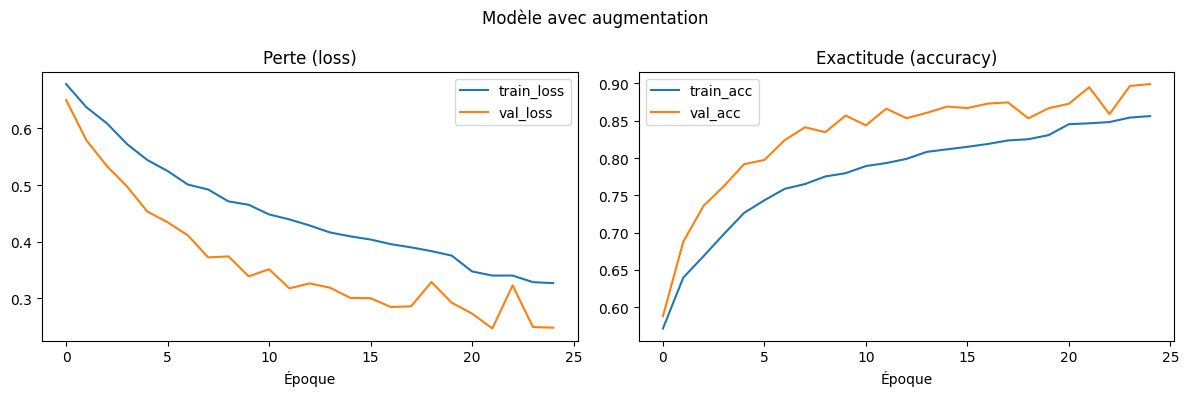

In [ ]:
def plot_history(history, title="Courbes d'entraînement"):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist['loss'], label='train_loss')
    axes[0].plot(hist['val_loss'], label='val_loss')
    axes[0].set_title('Perte (loss)')
    axes[0].set_xlabel('Époque')
    axes[0].legend()

    axes[1].plot(hist['accuracy'], label='train_acc')
    axes[1].plot(hist['val_accuracy'], label='val_acc')
    axes[1].set_title('Exactitude (accuracy)')
    axes[1].set_xlabel('Époque')
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history, "Modèle avec augmentation")


**Détection du surapprentissage** : on observe un surapprentissage lorsque la perte
d'entraînement continue de baisser alors que la perte de validation stagne, puis remonte
(les deux courbes divergent). Si c'est le cas ici, les leviers d'atténuation possibles sont :
augmenter encore la donnée (augmentation plus agressive), augmenter le taux de `Dropout`,
réduire le nombre de paramètres du modèle (moins de filtres / couches), ou utiliser la
régularisation L2. `EarlyStopping` permet déjà de limiter l'impact en restaurant les
meilleurs poids observés sur la validation.


## 6. Évaluation sur les données de validation

### À faire

Calcul de la perte/exactitude de validation, matrice de confusion, précision et rappel
par classe.

> **Point important** : pour une sortie sigmoïde, le seuil de 0.5 est arbitraire ; il doit
> être calibré/ajusté selon la métrique cible (ex. maximiser le F1, ou privilégier le rappel
> d'une classe si les faux négatifs sont plus coûteux que les faux positifs).


157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 283ms/step - accuracy: 0.8950 - auc: 0.9655 - loss: 0.2469
Validation loss: 0.2469 | accuracy: 0.8950 | AUC: 0.9655
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 246ms/step


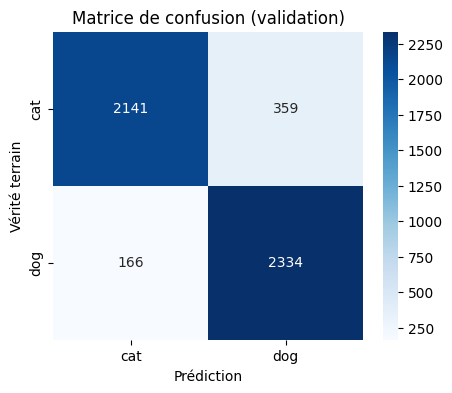

              precision    recall  f1-score   support

         cat       0.93      0.86      0.89      2500
         dog       0.87      0.93      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.89      5000
weighted avg       0.90      0.90      0.89      5000



In [ ]:
val_loss, val_acc, val_auc = model.evaluate(val_flow)
print(f"Validation loss: {val_loss:.4f} | accuracy: {val_acc:.4f} | AUC: {val_auc:.4f}")

val_flow.reset()
y_true = val_flow.labels
y_prob = model.predict(val_flow).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
class_names = [inv_class_indices[0], inv_class_indices[1]]

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion (validation)')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


**Analyse à compléter manuellement** une fois les résultats obtenus : identifier quelle
classe concentre le plus d'erreurs (faux positifs vs faux négatifs) et formuler une
hypothèse — par exemple un biais de texture/couleur de pelage, ou des images d'arrière-plan
trompeuses — puis proposer un ajustement (seuil de décision, augmentation ciblée, plus de
données pour la classe en difficulté).


## 7. Inférence sur l'ensemble de test non étiqueté

### À faire

On génère les probabilités sur `test_flow`, on les convertit en étiquettes via un seuil de
0.5, puis on exporte un CSV avec les colonnes `filepath`, `prob_dog`, `pred_label`.


In [ ]:
test_flow.reset()
test_probs = model.predict(test_flow).ravel()  # proba de la classe '1' = dog (selon class_indices)
test_paths = test_flow.filepaths

# S'assurer du mapping correct dog -> proba
dog_index = class_indices.get('dog', 1)
prob_dog = test_probs if dog_index == 1 else (1 - test_probs)

pred_label = np.where(prob_dog >= 0.5, 'dog', 'cat')

df_predictions = pd.DataFrame({
    'filepath': test_paths,
    'prob_dog': prob_dog,
    'pred_label': pred_label,
})
df_predictions.to_csv('test_predictions.csv', index=False)
df_predictions.head()


391/391 ━━━━━━━━━━━━━━━━━━━━ 101s 257ms/step


,filepath,prob_dog,pred_label
0,data/test/test/6457.jpg,0.999957,dog
1,data/test/test/152.jpg,0.231463,cat
2,data/test/test/11684.jpg,0.103279,cat
3,data/test/test/439.jpg,0.958429,dog
4,data/test/test/5397.jpg,0.000030,cat


**Vérification manuelle** : on peut échantillonner aléatoirement ~10-15 lignes du CSV,
afficher l'image correspondante et comparer visuellement à `pred_label` pour s'assurer que
le pipeline d'inférence (mapping des classes, seuil, chemins de fichiers) est cohérent.


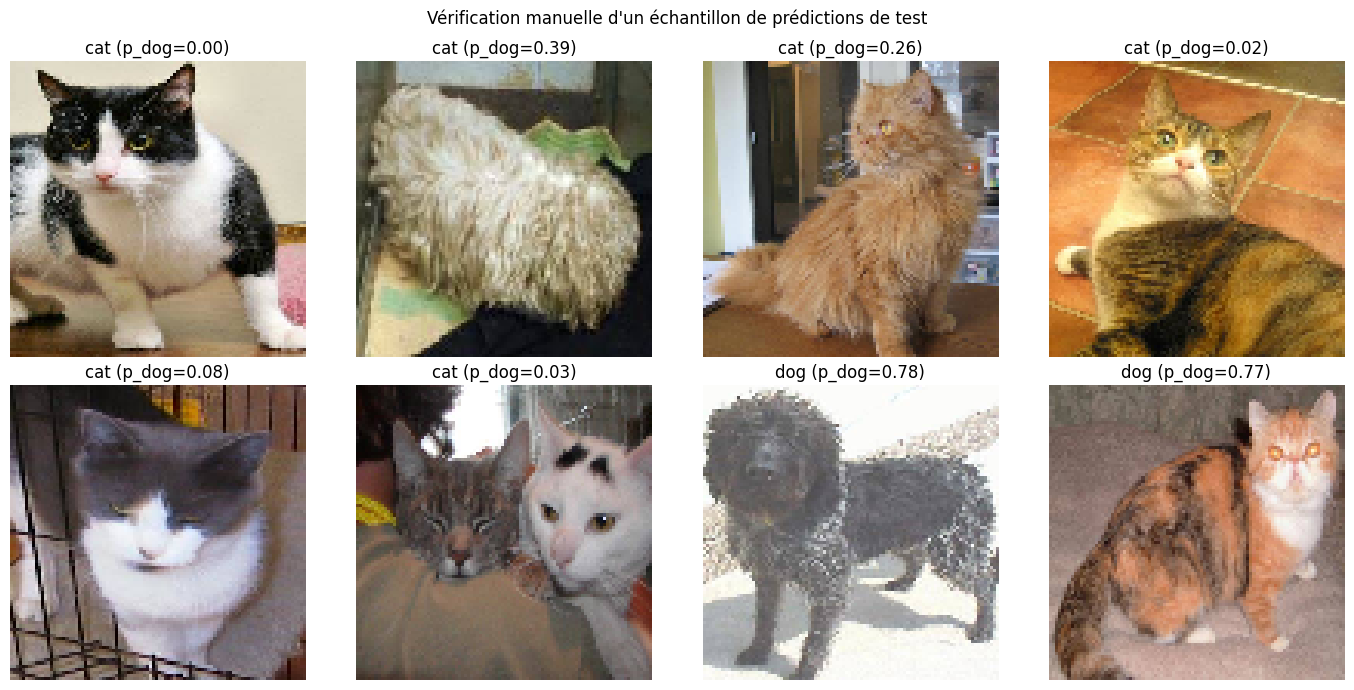

In [ ]:
sample = df_predictions.sample(8, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = keras.utils.load_img(row['filepath'], target_size=(IMG_HEIGHT, IMG_WIDTH))
    ax.imshow(img)
    ax.set_title(f"{row['pred_label']} (p_dog={row['prob_dog']:.2f})")
    ax.axis('off')
plt.suptitle("Vérification manuelle d'un échantillon de prédictions de test")
plt.tight_layout()
plt.show()


## 8. Comparer baseline (sans augmentation) et modèle augmenté

### À faire

On entraîne un modèle de même architecture, mais sur un générateur sans augmentation
(rescale uniquement), puis on compare aux résultats de la section 5.


Found 20000 non-validated image filenames belonging to 2 classes.
Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.5611 - auc: 0.5851 - loss: 0.6792

625/625 ━━━━━━━━━━━━━━━━━━━━ 534s 850ms/step - accuracy: 0.6111 - auc: 0.6652 - loss: 0.6454 - val_accuracy: 0.7292 - val_auc: 0.8149 - val_loss: 0.5283 - learning_rate: 0.0010
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.7241 - auc: 0.8004 - loss: 0.5417

625/625 ━━━━━━━━━━━━━━━━━━━━ 523s 838ms/step - accuracy: 0.7407 - auc: 0.8213 - loss: 0.5177 - val_accuracy: 0.7896 - val_auc: 0.8693 - val_loss: 0.4765 - learning_rate: 0.0010
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.7928 - auc: 0.8778 - loss: 0.4396

625/625 ━━━━━━━━━━━━━━━━━━━━ 528s 845ms/step - accuracy: 0.8045 - auc: 0.8882 - loss: 0.4219 - val_accuracy: 0.8362 - val_auc: 0.9156 - val_loss: 0.3731 - learning_rate: 0.0010
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8347 - auc: 0.9157 - loss: 0.3685

625/625 ━━━━━━━━━━━━━━━━━━━━ 529s 846ms/step - accuracy: 0.8439 - auc: 0.9221 - loss: 0.3558 - val_accuracy: 0.8582 - val_auc: 0.9393 - val_loss: 0.3216 - learning_rate: 0.0010
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.8732 - auc: 0.9454 - loss: 0.2989

625/625 ━━━━━━━━━━━━━━━━━━━━ 530s 847ms/step - accuracy: 0.8741 - auc: 0.9464 - loss: 0.2960 - val_accuracy: 0.8712 - val_auc: 0.9458 - val_loss: 0.3002 - learning_rate: 0.0010
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.8960 - auc: 0.9625 - loss: 0.2485

625/625 ━━━━━━━━━━━━━━━━━━━━ 540s 865ms/step - accuracy: 0.8939 - auc: 0.9607 - loss: 0.2548 - val_accuracy: 0.8694 - val_auc: 0.9517 - val_loss: 0.2937 - learning_rate: 0.0010
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.9048 - auc: 0.9688 - loss: 0.2264

625/625 ━━━━━━━━━━━━━━━━━━━━ 528s 845ms/step - accuracy: 0.9047 - auc: 0.9680 - loss: 0.2291 - val_accuracy: 0.8800 - val_auc: 0.9583 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.9237 - auc: 0.9780 - loss: 0.1892

625/625 ━━━━━━━━━━━━━━━━━━━━ 522s 835ms/step - accuracy: 0.9208 - auc: 0.9770 - loss: 0.1939 - val_accuracy: 0.8836 - val_auc: 0.9572 - val_loss: 0.2765 - learning_rate: 0.0010
Epoch 9/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.9311 - auc: 0.9822 - loss: 0.1704

625/625 ━━━━━━━━━━━━━━━━━━━━ 527s 843ms/step - accuracy: 0.9283 - auc: 0.9813 - loss: 0.1750 - val_accuracy: 0.8930 - val_auc: 0.9636 - val_loss: 0.2540 - learning_rate: 0.0010
Epoch 10/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 524s 839ms/step - accuracy: 0.9385 - auc: 0.9857 - loss: 0.1518 - val_accuracy: 0.8938 - val_auc: 0.9606 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 11/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 528s 845ms/step - accuracy: 0.9481 - auc: 0.9890 - loss: 0.1315 - val_accuracy: 0.8966 - val_auc: 0.9603 - val_loss: 0.2842 - learning_rate: 0.0010
Epoch 12/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 521s 834ms/step - accuracy: 0.9547 - auc: 0.9913 - loss: 0.1161 - val_accuracy: 0.8978 - val_auc: 0.9640 - val_loss: 0.2932 - learning_rate: 0.0010
Epoch 13/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 518s 829ms/step - accuracy: 0.9753 - auc: 0.9972 - loss: 0.0655 - val_accuracy: 0.9048 - val_auc: 0.9643 - val_loss: 0.3028 - learning_rate: 5.0000e-04
Epoch 14/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 521s 834ms/step - accu

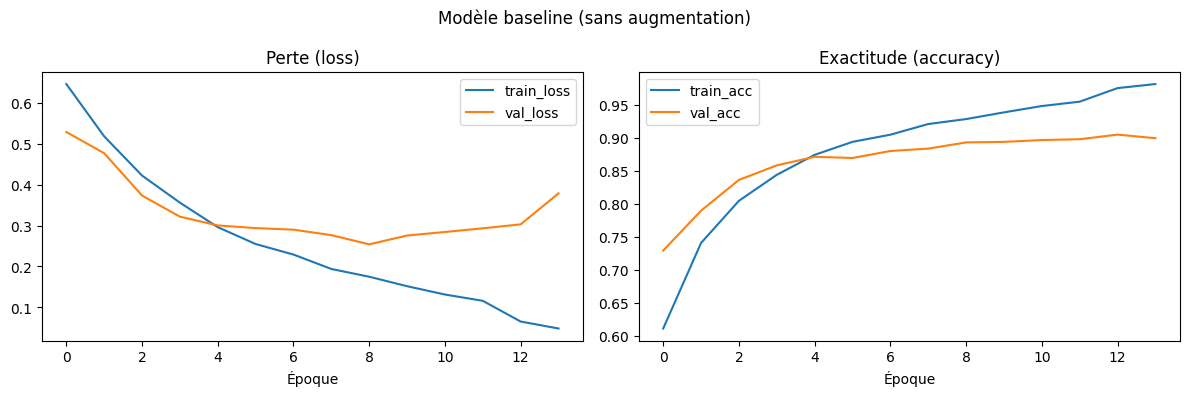

In [ ]:
train_datagen_baseline = ImageDataGenerator(rescale=1./255)

train_flow_baseline = train_datagen_baseline.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)

model_baseline = compile_model(build_cnn())

history_baseline = model_baseline.fit(
    train_flow_baseline,
    epochs=EPOCHS,
    validation_data=val_flow,
    callbacks=get_callbacks("model_baseline"),
)

plot_history(history_baseline, "Modèle baseline (sans augmentation)")


In [ ]:
baseline_val_loss, baseline_val_acc, baseline_val_auc = model_baseline.evaluate(val_flow)

comparison = pd.DataFrame({
    'Modèle': ['Baseline (sans augmentation)', 'Avec augmentation'],
    'Val Loss': [baseline_val_loss, val_loss],
    'Val Accuracy': [baseline_val_acc, val_acc],
    'Val AUC': [baseline_val_auc, val_auc],
})
comparison


157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 241ms/step - accuracy: 0.8930 - auc: 0.9636 - loss: 0.2540


,Modèle,Val Loss,Val Accuracy,Val AUC
0,Baseline (sans augmentation),0.254047,0.893,0.963573
1,Avec augmentation,0.246913,0.895,0.965524


**Analyse de l'écart de généralisation** (à affiner avec les valeurs obtenues) : le
modèle baseline tend à présenter un écart plus important entre la perte d'entraînement et
de validation (surapprentissage plus marqué), car il voit toujours les mêmes images exactes
à chaque époque. Le modèle augmenté voit des variations synthétiques (rotation, zoom,
décalage, flip) qui agissent comme un régularisateur implicite, réduisant généralement
l'écart train/val et améliorant la robustesse, parfois au prix d'une convergence
légèrement plus lente.

> **Leçon à retenir** : on privilégie les modifications qui améliorent la validation sans
> augmenter significativement le coût de calcul. L'augmentation de données en fait partie :
> coût quasi nul (transformations à la volée) pour un gain de généralisation souvent net.


## 9. Gestion du déséquilibre de classes

### À faire

Si le ratio calculé en section 2 indique un déséquilibre, on calcule les poids de classe et
on relance l'entraînement avec `class_weight`. Sur ce jeu de données, les classes sont en
principe quasi équilibrées ; le code ci-dessous reste néanmoins applicable tel quel.


In [ ]:
classes_unique = np.unique(labels_arr)
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=classes_unique, y=labels_arr
)
class_weight_dict = {int(c): w for c, w in zip(classes_unique, class_weights_arr)}
print("Poids de classes:", class_weight_dict)

model_weighted = compile_model(build_cnn())

history_weighted = model_weighted.fit(
    train_flow,
    epochs=EPOCHS,
    validation_data=val_flow,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("model_weighted"),
)

plot_history(history_weighted, "Modèle avec class_weight")


Poids de classes: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.5287 - auc: 0.5381 - loss: 0.6908

625/625 ━━━━━━━━━━━━━━━━━━━━ 585s 928ms/step - accuracy: 0.5594 - auc: 0.5844 - loss: 0.6831 - val_accuracy: 0.6598 - val_auc: 0.7225 - val_loss: 0.6375 - learning_rate: 0.0010
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 851ms/step - accuracy: 0.6315 - auc: 0.6767 - loss: 0.6474

625/625 ━━━━━━━━━━━━━━━━━━━━ 571s 913ms/step - accuracy: 0.6427 - auc: 0.6947 - loss: 0.6332 - val_accuracy: 0.7330 - val_auc: 0.8033 - val_loss: 0.5499 - learning_rate: 0.0010
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.6761 - auc: 0.7418 - loss: 0.5981

625/625 ━━━━━━━━━━━━━━━━━━━━ 570s 913ms/step - accuracy: 0.6866 - auc: 0.7519 - loss: 0.5908 - val_accuracy: 0.7494 - val_auc: 0.8354 - val_loss: 0.5127 - learning_rate: 0.0010
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.7000 - auc: 0.7670 - loss: 0.5765

625/625 ━━━━━━━━━━━━━━━━━━━━ 572s 915ms/step - accuracy: 0.7046 - auc: 0.7768 - loss: 0.5662 - val_accuracy: 0.7834 - val_auc: 0.8644 - val_loss: 0.4694 - learning_rate: 0.0010
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 575s 920ms/step - accuracy: 0.7194 - auc: 0.7939 - loss: 0.5480 - val_accuracy: 0.7572 - val_auc: 0.8697 - val_loss: 0.4995 - learning_rate: 0.0010
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.7316 - auc: 0.8073 - loss: 0.5354

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 578s 924ms/step - accuracy: 0.7958 - auc: 0.8798 - loss: 0.4340 - val_accuracy: 0.8500 - val_auc: 0.9363 - val_loss: 0.3428 - learning_rate: 0.0010
Epoch 14/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 569s 910ms/step - accuracy: 0.7974 - auc: 0.8820 - loss: 0.4302 - val_accuracy: 0.8414 - val_auc: 0.9413 - val_loss: 0.3551 - learning_rate: 0.0010
Epoch 15/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 569s 911ms/step - accuracy: 0.8084 - auc: 0.8909 - loss: 0.4165 - val_accuracy: 0.8360 - val_auc: 0.9456 - val_loss: 0.3680 - learning_rate: 0.0010
Epoch 16/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.8050 - auc: 0.8904 - loss: 0.4182

625/625 ━━━━━━━━━━━━━━━━━━━━ 573s 917ms/step - accuracy: 0.8094 - auc: 0.8917 - loss: 0.4167 - val_accuracy: 0.8560 - val_auc: 0.9443 - val_loss: 0.3267 - learning_rate: 0.0010
Epoch 17/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.8124 - auc: 0.8967 - loss: 0.4061

625/625 ━━━━━━━━━━━━━━━━━━━━ 574s 918ms/step - accuracy: 0.8145 - auc: 0.8975 - loss: 0.4054 - val_accuracy: 0.8674 - val_auc: 0.9448 - val_loss: 0.3171 - learning_rate: 0.0010
Epoch 18/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.8136 - auc: 0.9008 - loss: 0.3994

625/625 ━━━━━━━━━━━━━━━━━━━━ 574s 919ms/step - accuracy: 0.8195 - auc: 0.9031 - loss: 0.3953 - val_accuracy: 0.8768 - val_auc: 0.9525 - val_loss: 0.2895 - learning_rate: 0.0010
Epoch 19/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 581s 930ms/step - accuracy: 0.8214 - auc: 0.9036 - loss: 0.3926 - val_accuracy: 0.8650 - val_auc: 0.9475 - val_loss: 0.3017 - learning_rate: 0.0010
Epoch 20/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 574s 919ms/step - accuracy: 0.8237 - auc: 0.9060 - loss: 0.3885 - val_accuracy: 0.8790 - val_auc: 0.9499 - val_loss: 0.2940 - learning_rate: 0.0010
Epoch 21/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 867ms/step - accuracy: 0.8279 - auc: 0.9072 - loss: 0.3865

625/625 ━━━━━━━━━━━━━━━━━━━━ 581s 930ms/step - accuracy: 0.8267 - auc: 0.9080 - loss: 0.3842 - val_accuracy: 0.8854 - val_auc: 0.9558 - val_loss: 0.2715 - learning_rate: 0.0010
Epoch 22/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 585s 937ms/step - accuracy: 0.8302 - auc: 0.9104 - loss: 0.3802 - val_accuracy: 0.8786 - val_auc: 0.9566 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 23/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 583s 933ms/step - accuracy: 0.8325 - auc: 0.9141 - loss: 0.3718 - val_accuracy: 0.8748 - val_auc: 0.9569 - val_loss: 0.2833 - learning_rate: 0.0010
Epoch 24/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 578s 924ms/step - accuracy: 0.8359 - auc: 0.9167 - loss: 0.3672 - val_accuracy: 0.8656 - val_auc: 0.9595 - val_loss: 0.3086 - learning_rate: 0.0010
Epoch 25/25
556/625 ━━━━━━━━━━━━━━━━━━━━ 59s 856ms/step - accuracy: 0.8390 - auc: 0.9222 - loss: 0.3538

**Effet attendu sur précision/rappel de la classe minoritaire** : pondérer la perte
augmente la pénalité associée aux erreurs sur la classe minoritaire, ce qui tend à
**augmenter son rappel** (moins de faux négatifs pour cette classe) au prix, potentiellement,
d'une **légère baisse de précision** globale (le modèle devient plus "généreux" à prédire
cette classe). Si les classes sont déjà équilibrées (cas attendu ici), l'effet de
`class_weight` sera marginal.


## 10. Conserver les artefacts pour réutilisation

### À faire

On sauvegarde le meilleur modèle (poids + architecture) et la configuration d'entraînement
dans un fichier JSON, afin d'assurer la reproductibilité de l'expérience.


In [32]:
BEST_MODEL_PATH = "model_augmented_final.h5"
model.save(BEST_MODEL_PATH)

config = {
    "img_height": IMG_HEIGHT,
    "img_width": IMG_WIDTH,
    "batch_size": batch_size,
    "learning_rate": LEARNING_RATE,
    "epochs_requested": EPOCHS,
    "optimizer": "Adam",
    "loss": "binary_crossentropy",
    "class_indices": class_indices,
    "augmentation": {
        "rotation_range": 45,
        "width_shift_range": 0.15,
        "height_shift_range": 0.15,
        "zoom_range": 0.5,
        "horizontal_flip": True,
    },
    "seed": seed,
}

with open("training_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Modèle sauvegardé:", BEST_MODEL_PATH)
print("Configuration sauvegardée: training_config.json")


Modèle sauvegardé: model_augmented_final.h5
Configuration sauvegardée: training_config.json


**Pourquoi sauvegarder poids ET métadonnées** : les poids seuls ne suffisent pas à
reproduire une expérience — sans connaître la résolution d'image, le mapping des classes, les
paramètres d'augmentation ou le taux d'apprentissage utilisés, il est impossible de réutiliser
correctement le modèle (pré-traitement incohérent) ou de comprendre dans quelles conditions
les métriques rapportées ont été obtenues.


## 11. Extensions

### À faire — Proposition argumentée

On retient ici **l'apprentissage par transfert avec MobileNetV2** (backbone léger, pré-entraîné
sur ImageNet, gelé) :

- **Bénéfice attendu** : MobileNetV2 a déjà appris des caractéristiques génériques de bas
  niveau (contours, textures) et intermédiaires sur des millions d'images naturelles. Cela
  permet d'atteindre une bien meilleure exactitude avec beaucoup moins d'images
  d'entraînement et un temps d'entraînement réduit, puisque seule une petite tête de
  classification est entraînée from scratch.
- Alternative : la **Batch Normalization** après les convolutions stabiliserait et
  accélèrerait la convergence ; l'**entraînement en précision mixte** (`mixed_float16`)
  accélèrerait l'entraînement sur GPU récents sans perte notable de précision.

Implémentation de l'option retenue (transfer learning) :


In [33]:
def build_transfer_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    base_model = keras.applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights='imagenet'
    )
    base_model.trainable = False  # backbone gelé

    inputs = keras.Input(shape=input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)  # nos flows rescale déjà /255
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs)

transfer_model = compile_model(build_transfer_model())
transfer_model.summary()

# Entraînement rapide de la tête de classification (décommenter pour exécuter)
# history_transfer = transfer_model.fit(
#     train_flow, epochs=10, validation_data=val_flow,
#     callbacks=get_callbacks("model_transfer")
# )


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 12. Liste de contrôle des livrables

- [x] Rapport de données : répartition par classe (section 2) + grille d'exemples annotés
- [x] Description du modèle et justification de l'optimisation (sections 3 et 4, texte)
- [x] Courbes d'entraînement / validation avec interprétation (section 5)
- [x] Métriques de validation : matrice de confusion, précision/rappel (section 6)
- [x] CSV des prédictions de test avec `filepath`, `prob_dog`, `pred_label` (section 7,
      fichier `test_predictions.csv`)
- [x] Modèle sauvegardé (`model_augmented_final.h5`) + configuration (`training_config.json`)
      (section 10)
- [x] Comparaison baseline vs augmentation (section 8)
- [x] Gestion du déséquilibre de classes (section 9)
- [x] Extension proposée et implémentée : transfer learning MobileNetV2 (section 11)

### Rappels rapides
- Le générateur d'entraînement (`train_flow`) sert uniquement à l'apprentissage, jamais à la
  validation ni au test.
- La répartition train/val (`seed=1337`, `test_size=0.2`) reste fixe pour comparer les
  expériences de façon cohérente.
- En cas de résultat suspect, vérifier en priorité les étiquettes et chemins de fichiers
  avant de remettre en cause le modèle.
